# Week 1: Epsilon-Greedy Action Selection in the 10-Armed Bandit Problem

This notebook explains the Week 1 implementation, runs the main experiments, and visualises the results using reusable code from `src/`.

## Problem Setup

The multi-armed bandit problem isolates the exploration-exploitation tradeoff. The agent repeatedly chooses one of several actions, receives an immediate reward, and must learn which action is best without seeing the true action values directly.

## Imports

The notebook imports the Week 1 implementation from `src/` so the reusable logic stays outside the notebook.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.bandits.environment import TenArmedBandit
from src.bandits.agents import EpsilonGreedyAgent
from src.bandits.experiments import run_single_experiment, run_multiple_experiments
from src.utils.plotting import plot_average_reward, plot_optimal_action_percentage

## 10-Armed Bandit Environment

In the 10-armed testbed, each action has a hidden true value sampled from a normal distribution. When the agent chooses an action, the observed reward is another noisy sample centred on that action's true value.

In [3]:
bandit = TenArmedBandit(seed=0)
print("Number of actions:", bandit.n_actions)
print("True action values:", bandit.q_true)
print("Optimal action:", bandit.optimal_action)

Number of actions: 10
True action values: [ 0.12573022 -0.13210486  0.64042265  0.10490012 -0.53566937  0.36159505
  1.30400005  0.94708096 -0.70373524 -1.26542147]
Optimal action: 6


## Quick Environment Test

A quick reward sample helps verify that the environment returns floating-point rewards for valid actions.

In [4]:
sample_reward = bandit.step(0)
print("Sample reward from action 0:", sample_reward)
print("Reward type:", type(sample_reward))

Sample reward from action 0: -0.4975442414439589
Reward type: <class 'float'>


## Action-Value Estimation

The agent does not know the true values `q*(a)`. Instead, it maintains estimates `Q(a)` and updates them using the sample-average rule:

`Q_new = Q_old + (reward - Q_old) / N`

## Epsilon-Greedy Action Selection

Greedy action selection always chooses the action with the highest current estimate. Epsilon-greedy keeps that behaviour most of the time, but with probability `epsilon` it explores by choosing a random action. This reduces the risk of committing too early to a poor action.

In [5]:
agent = EpsilonGreedyAgent(n_actions=10, epsilon=0.1, seed=0)
print("Initial estimates:", agent.q_estimates)
action = agent.select_action()
reward = bandit.step(action)
agent.update(action, reward)
print("Selected action:", action)
print("Updated estimate for selected action:", agent.q_estimates[action])
print("Action counts:", agent.action_counts)

Initial estimates: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Selected action: 5
Updated estimate for selected action: 0.4029210342567283
Action counts: [0 0 0 0 0 1 0 0 0 0]


## Quick Agent Test

After one interaction, the chosen action should have count `1`, and its estimated value should move toward the observed reward.

## Single Experiment

A single experiment creates one bandit instance and one epsilon-greedy agent, then records the reward and whether the optimal action was selected at each step.

In [6]:
rewards, optimal_action_selected = run_single_experiment(epsilon=0.1, n_steps=1000, n_actions=10, seed=0)
print("Rewards shape:", rewards.shape)
print("Optimal-action indicators shape:", optimal_action_selected.shape)
print("First 5 rewards:", rewards[:5])

Rewards shape: (1000,)
Optimal-action indicators shape: (1000,)
First 5 rewards: [-0.26167941  0.68174863 -2.45713564  0.42163099 -0.6054883 ]


## Single Experiment Test

This sanity check confirms the runner returns one reward trace and one optimal-action trace for the requested number of steps.

## Why Multiple Runs Are Needed

A single bandit run is noisy because the true action values, reward samples, and early exploratory choices are all random. To compare policies fairly, we average over many independent runs.

## Main Experiment Setup

Week 1 compares three exploration settings: `epsilon = 0`, `epsilon = 0.01`, and `epsilon = 0.1`.

In [7]:
epsilons = [0, 0.01, 0.1]
results = run_multiple_experiments(epsilons=epsilons, n_runs=200, n_steps=1000, n_actions=10, seed=0)
results.keys()

dict_keys([0, 0.01, 0.1])

## Average Reward Plot

Average reward measures how much reward each strategy receives over time on average. If a method learns to favour better actions, this curve should improve.

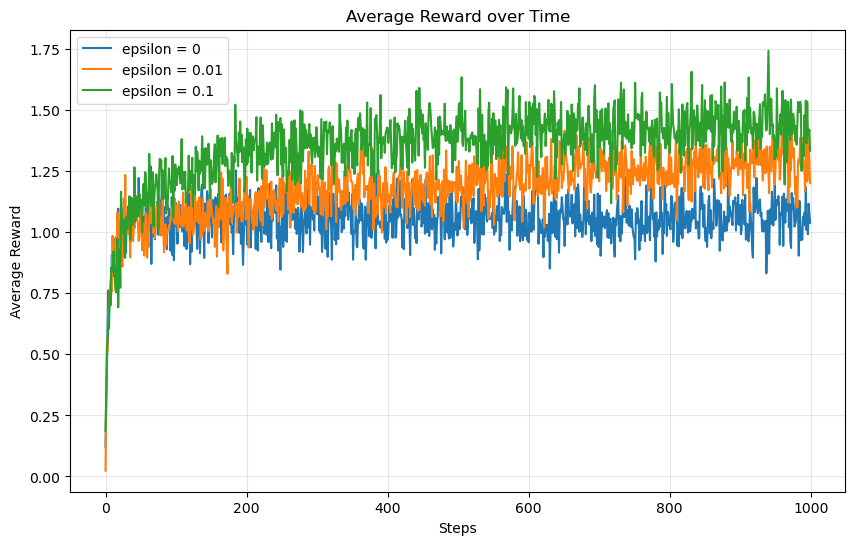

In [8]:
plot_average_reward(results)

## Optimal Action Percentage Plot

Percentage optimal action measures how often the agent selects the truly best arm in each bandit instance. This complements average reward by showing how reliably the agent identifies the optimal action.

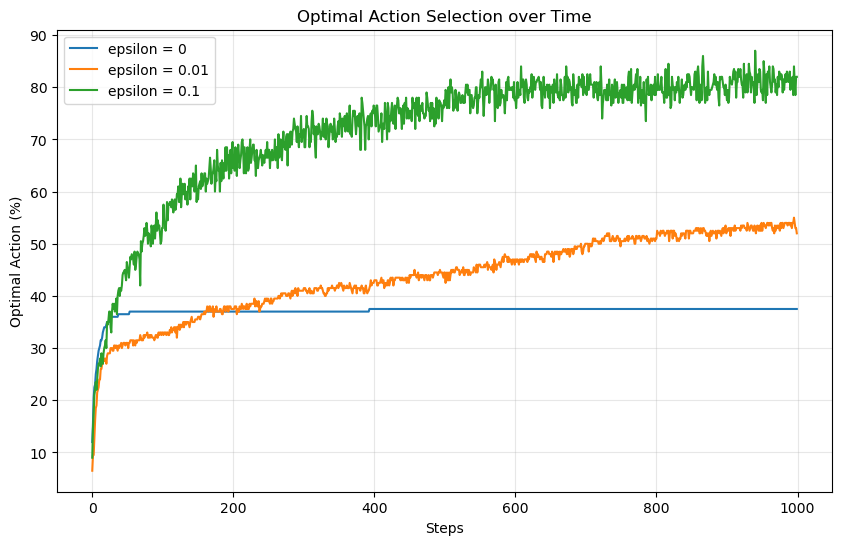

In [9]:
plot_optimal_action_percentage(results)

## Save Results

The plots are saved to `results/week_01/` so Week 1 outputs stay grouped together.

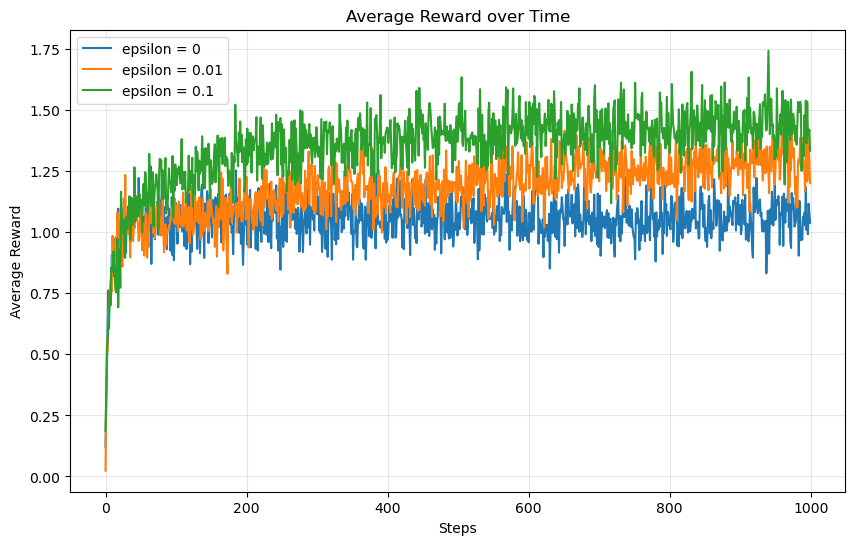

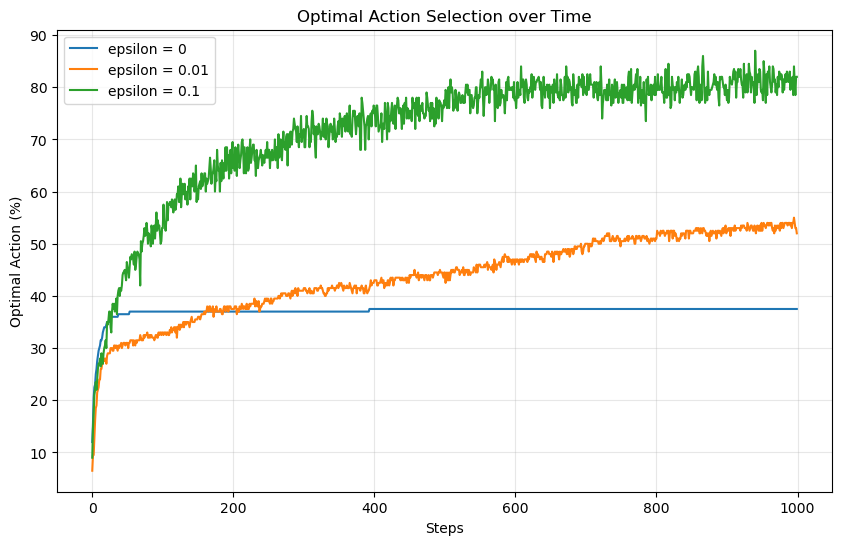

Saved files to: D:\Machine_Learning_projects\RL_Projects\reinforcement-learning-series\results\week_01


In [10]:
results_dir = PROJECT_ROOT / "results" / "week_01"
plot_average_reward(results, save_path=results_dir / "average_reward.png")
plot_optimal_action_percentage(results, save_path=results_dir / "optimal_action_percentage.png")
print("Saved files to:", results_dir)

## Final Interpretation

Pure greedy action selection can look acceptable early on, but it may stop exploring after a few lucky outcomes. Epsilon-greedy continues gathering information, which improves long-run performance and increases the chance of finding the optimal arm.

## Technical Takeaways

- The environment and agent logic belong in `src/`, not inside the notebook.
- Sample-average updates are enough to build a clean first bandit agent.
- Multiple independent runs are necessary for stable comparisons.
- Organising outputs in `results/week_01/` keeps the series clean as new weeks are added.